In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
train_dir = '/content/drive/MyDrive/Data for Models/MRI VS NOT_MRI'

for label in ["MRI_IMG", "NOT_MRI_IMG"]:
    print(label, "Train_Images:", len(os.listdir(os.path.join(train_dir, label))))

MRI_IMG Train_Images: 3165
NOT_MRI_IMG Train_Images: 3385


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

# Data augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

In [4]:
# Training Data
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True
)

# Validation Data
val_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False  # IMPORTANT: shuffle=False for correct evaluation
)

print("Class indices:", train_generator.class_indices)
# MRI_IMG -> 0, NOT_MRI_IMG -> 1 (alphabetical order)

Found 5240 images belonging to 2 classes.
Found 1310 images belonging to 2 classes.
Class indices: {'MRI_IMG': 0, 'NOT_MRI_IMG': 1}


In [5]:
# Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
# Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // 32,
    validation_data=val_generator,
    validation_steps=val_generator.samples // 32,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 910s 5s/step - accuracy: 0.9921 - loss: 0.0202 - val_accuracy: 1.0000 - val_loss: 9.8425e-04 - learning_rate: 0.0010
Epoch 2/20
  1/163 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.9375 - loss: 0.1344

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


163/163 ━━━━━━━━━━━━━━━━━━━━ 20s 123ms/step - accuracy: 0.9375 - loss: 0.1344 - val_accuracy: 0.9984 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 665ms/step - accuracy: 0.9987 - loss: 0.0043 - val_accuracy: 0.9953 - val_loss: 0.0106 - learning_rate: 0.0010
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 247ms/step - accuracy: 1.0000 - loss: 1.7981e-04 - val_accuracy: 0.9945 - val_loss: 0.0127 - learning_rate: 0.0010
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 143s 876ms/step - accuracy: 0.9988 - loss: 0.0021 - val_accuracy: 0.9992 - val_loss: 0.0032 - learning_rate: 5.0000e-04
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 20s 124ms/step - accuracy: 1.0000 - loss: 2.6922e-05 - val_accuracy: 0.9977 - val_loss: 0.0054 - learning_rate: 5.0000e-04


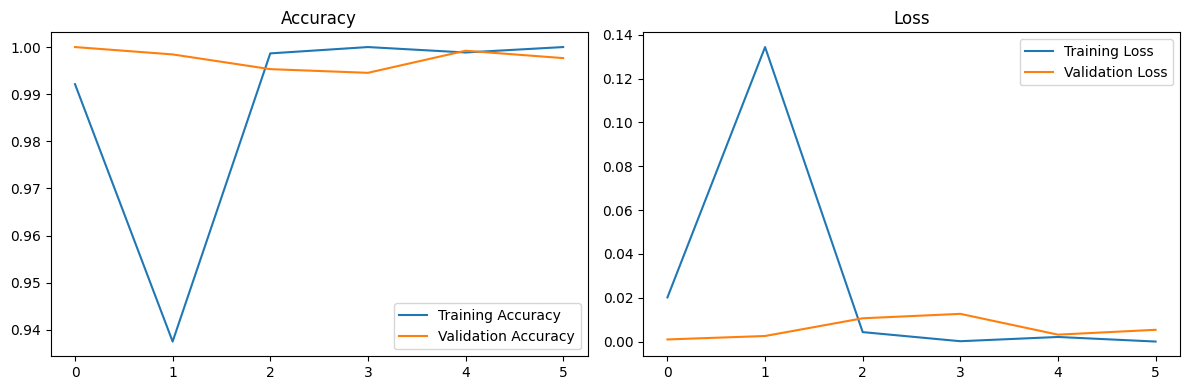

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.tight_layout()
plt.show()

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Reset generator before predict
val_generator.reset()

Y_pred_prob = model.predict(val_generator, steps=val_generator.samples // 32 + 1)
Y_pred_prob = Y_pred_prob.flatten()  # (N,1) -> (N,)

y_pred = (Y_pred_prob >= 0.5).astype(int)

# True labels
y_true = val_generator.classes

# Trim to same length (steps*batch_size might overshoot)
min_len = min(len(y_true), len(y_pred))
y_true = y_true[:min_len]
y_pred = y_pred[:min_len]

class_labels = list(val_generator.class_indices.keys())
print("Class labels:", class_labels)
print()
print(classification_report(y_true, y_pred, target_names=class_labels))

41/41 ━━━━━━━━━━━━━━━━━━━━ 43s 915ms/step
Class labels: ['MRI_IMG', 'NOT_MRI_IMG']

              precision    recall  f1-score   support

     MRI_IMG       1.00      1.00      1.00       633
 NOT_MRI_IMG       1.00      1.00      1.00       677

    accuracy                           1.00      1310
   macro avg       1.00      1.00      1.00      1310
weighted avg       1.00      1.00      1.00      1310



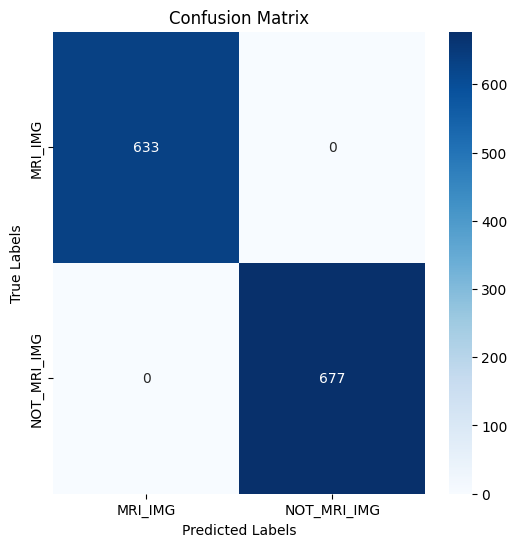

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [11]:
model.save('/content/drive/MyDrive/Trained Saved Models/MRI_NOT_MRI.keras')
model.save('/content/drive/MyDrive/Trained Saved Models/MRI_NOT_MRI.h5')